# 3.1 基础课程总览：从数据语义到模型训练

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

用一张循序递进的路线图串起六门数学与机器学习基础课，以及最后的数据实验管线。这里建立共同语言和最小手算直觉；完整教学沿 3.2—3.8 逐课展开。

## Setup

本 Notebook 的默认真实数据是 **MovieLens latest-small（smoke 确定性切片）；full 用官方完整 MovieLens latest（约 33M 评分）**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [MIT OCW Linear Algebra](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/) · [Google ML Crash Course: Logistic Regression](https://developers.google.com/machine-learning/crash-course/logistic-regression) · [scikit-learn Model Evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "movielens"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'movielens', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## Steps

## 0. 3.0 渐进学习路线与算法依赖图

3.0 负责建立所有算法共用的语言；算法页只展开论文新引入的结构与公式。建议按表格从上到下学习，遇到熟悉内容也可直接跳到对应的精确小节；六门概念课之后，再进入 [3.8 数据与实验基础](/notebooks/3_8_data_pipeline)：

| 共同领域 | 先掌握什么 | 后续主要用在 |
|---|---|---|
| 数据与机器学习 | [一行数据、特征与标签](/notebooks/3_2_data_ml_basics#observation-label)；[显式/隐式反馈、曝光、未知与假负例](/notebooks/3_2_data_ml_basics#implicit-feedback)；[切分、泄漏与泛化](/notebooks/3_2_data_ml_basics#split-leakage) | 全部章节的数据协议与结果边界 |
| 线性代数 | [张量形状与轴](/notebooks/3_3_linear_algebra#tensors-shapes)；[逐元素运算、点积与余弦](/notebooks/3_3_linear_algebra#elementwise-dot)；[矩阵乘法与 embedding](/notebooks/3_3_linear_algebra#matmul-embedding) | CF、MF、FM、双塔、注意力 |
| 微积分 | [函数与复合](/notebooks/3_4_calculus#functions)；[偏导与梯度](/notebooks/3_4_calculus#derivative-gradient)；[链式法则与反向传播](/notebooks/3_4_calculus#chain-rule) | 所有需要训练参数的模型 |
| 概率与统计 | [条件概率](/notebooks/3_5_probability_statistics#conditional-chain)；[期望与方差](/notebooks/3_5_probability_statistics#expectation-variance)；[odds、logit 与校准](/notebooks/3_5_probability_statistics#likelihood-calibration) | CTR、多任务、序列生成与实验解读 |
| 信息论 | [交叉熵与 KL](/notebooks/3_6_information_theory#cross-entropy-kl)；[Softmax、温度与 NE](/notebooks/3_6_information_theory#softmax-temperature)；[序列 NLL](/notebooks/3_6_information_theory#sequence-nll-dpo) | LR/GBDT、word2vec、DSSM、Transformer |
| 优化 | [SGD 与 mini-batch](/notebooks/3_7_optimization#sgd)；[学习率](/notebooks/3_7_optimization#learning-rate)；[正则化、过拟合与早停](/notebooks/3_7_optimization#regularization) | MF、深度模型、生成式模型 |

依赖顺序可以压成一句话：**先说明一行数据代表什么 → 写出数组形状与运算 → 把模型看成复合函数 → 用概率定义预测与损失 → 用梯度和小批次优化 → 用指标检查泛化。**

## 1. 从“行为表”到矩阵

推荐系统最原始的数据不是公式，而是一张行为表：谁在什么时间看了什么。为了同时观察许多用户与物品，我们把它整理成矩阵 $R$：

- 每一行是一位用户；
- 每一列是一个物品；
- 数字 1 表示发生过喜欢/点击，0 表示没有观察到；
- $R\in\mathbb R^{3\times4}$ 只是在说“这张表有 3 行、4 列”。

注意数据语义不能混用：星级是用户主动给出的**显式反馈**；点击/观看是行为留下的**隐式反馈**；“曝光后未点击”才是有明确分母的负标签；从未曝光或日志未记录通常只能叫**未知**。从未知项抽作负样本会产生**假负例**，必须记录采样规则。完整例子见 [3.2 显式、隐式反馈与未知项](/notebooks/3_2_data_ml_basics#implicit-feedback)。

,i0,i1,i2,i3
u0,1.0,1.0,0.0,0.0
u1,1.0,0.0,1.0,0.0
u2,0.0,1.0,1.0,1.0


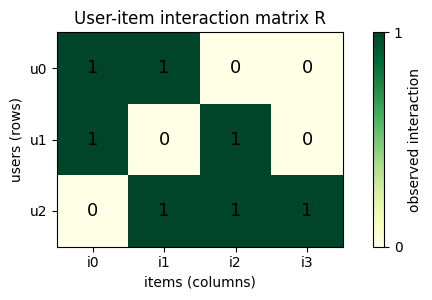

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

users = ["u0", "u1", "u2"]
items = ["i0", "i1", "i2", "i3"]
R = np.array([
    [1, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 1, 1],
], dtype=float)

display(pd.DataFrame(R, index=users, columns=items))
fig, ax = plt.subplots(figsize=(6.4, 3.1))
image = ax.imshow(R, cmap="YlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(items)), items); ax.set_yticks(range(len(users)), users)
ax.set_xlabel("items (columns)"); ax.set_ylabel("users (rows)")
for row in range(R.shape[0]):
    for col in range(R.shape[1]): ax.text(col, row, int(R[row, col]), ha="center", va="center", fontsize=13)
ax.set_title("User-item interaction matrix R")
plt.colorbar(image, ax=ax, ticks=[0, 1], label="observed interaction")
plt.tight_layout(); plt.show()

### 1.1 向量只是“一行数字”

用户 `u0` 的行为向量是 $[1,1,0,0]$。四个位置像四个问题的答案：“看过 i0 吗？看过 i1 吗？……”因此向量不是抽象符号，而是把一个对象沿多个维度描述成一行数字。

向量的**长度**使用勾股定理：$\|a\|_2=\sqrt{a_1^2+\cdots+a_n^2}$。`u0` 有两个 1，所以长度是 $\sqrt2$。

In [3]:
u0 = R[0]
u1 = R[1]
print({"u0 vector": u0.tolist(), "u0 length": np.linalg.norm(u0), "expected": np.sqrt(2)})
assert np.isclose(np.linalg.norm(u0), np.sqrt(2))

{'u0 vector': [1.0, 1.0, 0.0, 0.0], 'u0 length': np.float64(1.4142135623730951), 'expected': np.float64(1.4142135623730951)}


## 2. 点积与余弦：把“共同选择”变成相似度

两个等长向量逐位置相乘再求和，叫作**点积**：

$$a\cdot b=a_1b_1+a_2b_2+\cdots+a_nb_n$$

对 0/1 行为来说，只有“两个人都为 1”的位置会贡献 1，所以点积正好数出共同选择。`u0·u1 = 1`，因为两人共同看过 i0。

但活跃用户可能仅仅因为看得多而获得更大点积。余弦相似度再除以两人的向量长度，把答案压到 0～1：

$$\cos(a,b)=\frac{a\cdot b}{\|a\|_2\|b\|_2}$$

可以把它理解为“方向有多一致”：1 表示选择比例完全一致，0 表示没有共同选择。

{'common choices / dot product': 1.0, 'cosine similarity': np.float64(0.5)}


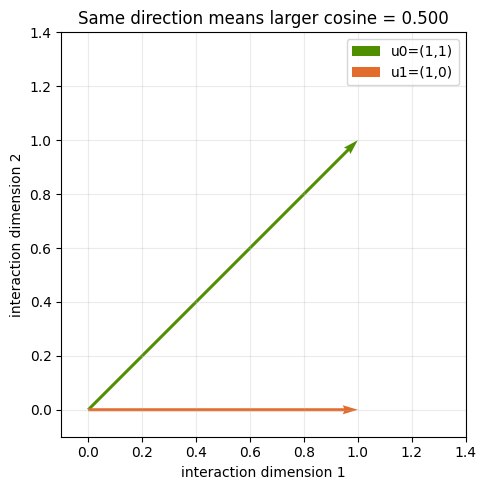

In [4]:
dot = float(u0 @ u1)
cosine = dot / (np.linalg.norm(u0) * np.linalg.norm(u1))
print({"common choices / dot product": dot, "cosine similarity": round(cosine, 3)})

fig, ax = plt.subplots(figsize=(5.4, 5.0))
a2, b2 = np.array([1, 1]), np.array([1, 0])
ax.quiver(0, 0, *a2, angles="xy", scale_units="xy", scale=1, color="#4f8f00", label="u0=(1,1)")
ax.quiver(0, 0, *b2, angles="xy", scale_units="xy", scale=1, color="#e36b2c", label="u1=(1,0)")
ax.set_xlim(-.1, 1.4); ax.set_ylim(-.1, 1.4); ax.set_aspect("equal")
ax.grid(alpha=.25); ax.legend(); ax.set_title(f"Same direction means larger cosine = {cosine:.3f}")
ax.set_xlabel("interaction dimension 1"); ax.set_ylabel("interaction dimension 2")
plt.tight_layout(); plt.show()

## 3. 矩阵乘法：一次完成许多次点积

矩阵乘法没有增加新的神秘规则，它只是批量点积：

- $R R^\top$：每个用户与每个用户做点积，得到用户共现矩阵；
- $R^\top R$：每个物品与每个物品做点积，得到物品共现矩阵。

乘法能否进行，只需检查“中间尺寸相同”。$R$ 是 $3\times4$，$R^\top$ 是 $4\times3$，所以 $(3\times4)(4\times3)$ 得到 $3\times3$。

先看**轴与形状**再看公式：批次张量 $(B,L,d)$ 的三个轴通常是样本、序列位置、特征。`a * b` 的逐元素乘法保留每个位置，结果仍是向量；`a @ b` 的点积会把对应位置乘积求和，结果是一个数；矩阵乘法则批量做点积。程序允许广播不代表语义正确，完整手算见 [3.3 张量形状与轴](/notebooks/3_3_linear_algebra#tensors-shapes) 和 [逐元素运算与点积](/notebooks/3_3_linear_algebra#elementwise-dot)。

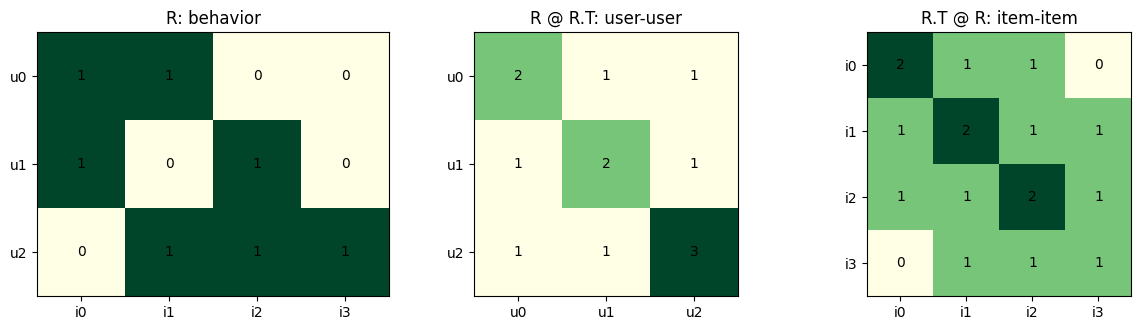

{'R': (3, 4), 'R @ R.T': (3, 3), 'R.T @ R': (4, 4)}


In [5]:
user_cooccurrence = R @ R.T
item_cooccurrence = R.T @ R
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, matrix, title, xlabels, ylabels in [
    (axes[0], R, "R: behavior", items, users),
    (axes[1], user_cooccurrence, "R @ R.T: user-user", users, users),
    (axes[2], item_cooccurrence, "R.T @ R: item-item", items, items),
]:
    ax.imshow(matrix, cmap="YlGn")
    ax.set_xticks(range(len(xlabels)), xlabels); ax.set_yticks(range(len(ylabels)), ylabels)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]): ax.text(col, row, int(matrix[row, col]), ha="center", va="center")
    ax.set_title(title)
plt.tight_layout(); plt.show()
print({"R": R.shape, "R @ R.T": user_cooccurrence.shape, "R.T @ R": item_cooccurrence.shape})

## 4. 概率、Sigmoid 与 LogLoss

排序模型常先输出任意实数 $z$，叫 **logit**。它可能是 -3、0 或 5，不能直接当概率。Sigmoid 把整条实数轴平滑压到 0～1：

$$p=\sigma(z)=\frac{1}{1+e^{-z}}$$

- $z=0$ 时 $p=0.5$，表示模型拿不准；
- $z$ 很大时概率接近 1；$z$ 很小时接近 0。

LogLoss 衡量概率预测有多糟。真实点击 $y=1$ 时，预测 0.9 只受很小惩罚，预测 0.01 会受到很大惩罚，因为模型“非常自信但答错了”：

$$L=-[y\log p+(1-y)\log(1-p)]$$

这里的指数与对数并不神秘：$e^z$ 会把加法尺度变成正的倍数尺度，$\log$ 是它的反函数，并把连乘变回相加。概率 $p$ 对应的 **odds** 是 $p/(1-p)$；取对数得到 $\log\frac{p}{1-p}=z$，所以 Sigmoid 正是在把 log-odds 还原成概率。若已知用户属于某人群 $B$，点击概率写成条件概率 $P(Y=1\mid B)$；许多样本的平均结果由期望 $E[Y]$ 描述。详见 [3.5 条件概率](/notebooks/3_5_probability_statistics#conditional-chain)、[期望与方差](/notebooks/3_5_probability_statistics#expectation-variance) 和 [odds、logit 与校准](/notebooks/3_5_probability_statistics#likelihood-calibration)。

最后要区分**排序**与**校准**：AUC 高只说明正例通常排在负例前；若模型给出 0.8 的一组样本长期只有约 50% 为正，它仍未校准。LogLoss 会惩罚这种概率误差，但上线前仍应画可靠性图。

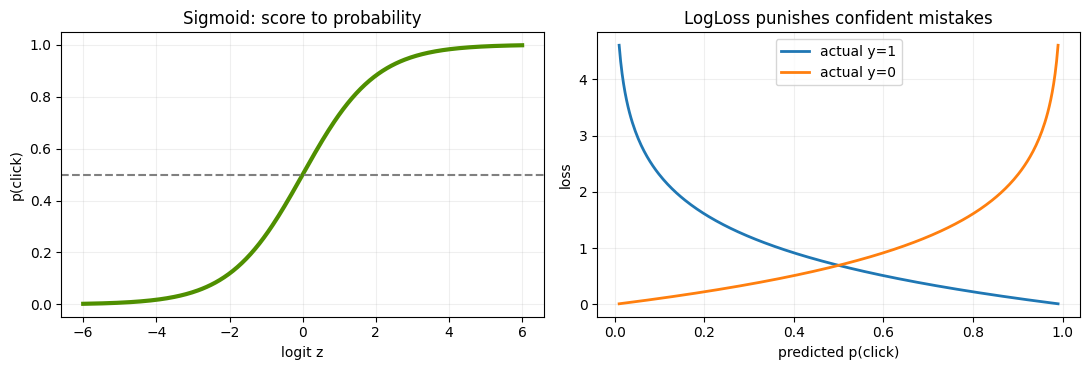

{'sigmoid(0)': 0.5, 'loss if y=1,p=.9': 0.105, 'loss if y=1,p=.01': 4.605}


In [6]:
logits = np.linspace(-6, 6, 300)
probabilities = 1 / (1 + np.exp(-logits))
p_grid = np.linspace(.01, .99, 300)
loss_when_clicked = -np.log(p_grid)
loss_when_not_clicked = -np.log(1 - p_grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(logits, probabilities, color="#4f8f00", lw=3); axes[0].axhline(.5, ls="--", color="gray")
axes[0].set(title="Sigmoid: score to probability", xlabel="logit z", ylabel="p(click)"); axes[0].grid(alpha=.2)
axes[1].plot(p_grid, loss_when_clicked, label="actual y=1", lw=2); axes[1].plot(p_grid, loss_when_not_clicked, label="actual y=0", lw=2)
axes[1].set(title="LogLoss punishes confident mistakes", xlabel="predicted p(click)", ylabel="loss"); axes[1].legend(); axes[1].grid(alpha=.2)
plt.tight_layout(); plt.show()
print({"sigmoid(0)": .5, "loss if y=1,p=.9": round(float(-np.log(.9)), 3), "loss if y=1,p=.01": round(float(-np.log(.01)), 3)})

## 5. Softmax、温度、加权汇总与遮罩

后续的 DSSM、MIND、DIN、SASRec、MMoE 会反复用到同一组操作：先算若干个分数，再把它们转成权重，最后汇总若干个向量。

Softmax 把任意实数 $z_1,\ldots,z_n$ 转成和为 1 的正数：

$$
\alpha_j=\frac{\exp(z_j/\tau)}{\sum_k\exp(z_k/\tau)},
\qquad \sum_j\alpha_j=1.
$$

$\tau$ 是温度：较小时权重更集中在最高分，较大时更平均。有了权重后，加权汇总就是

$$
v=\sum_j\alpha_j e_j.
$$

它可以理解为“每个历史向量 $e_j$ 贡献多少”。注意力只是让分数 $z_j$ 由当前 query 与 key 的匹配产生。对矩阵 $Q,K$ 通常写为

$$
S=\frac{QK^\top}{\sqrt d},\qquad A=\operatorname{softmax}(S+M),\qquad H=AV.
$$

$QK^\top$ 是批量点积；$\sqrt d$ 防止维数增大时分数过大；遮罩 $M$ 把不允许读取的位置设为 $-\infty$，Softmax 后它们的权重就是 0。序列模型用它阻止偷看未来，变长序列用它忽略 padding。

In [7]:
scores = np.array([1.0, 2.0, 4.0])
values = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])

def softmax_with_temperature(x, temperature=1.0):
    stable = x / temperature - np.max(x / temperature)
    weights = np.exp(stable)
    return weights / weights.sum()

for temperature in [0.5, 1.0, 2.0]:
    weights = softmax_with_temperature(scores, temperature)
    summary = weights @ values
    print({"temperature": temperature, "weights": weights.round(3).tolist(),
           "weighted vector": summary.round(3).tolist()})

masked_scores = np.array([1.0, 2.0, -np.inf])
masked_weights = softmax_with_temperature(masked_scores)
assert np.isclose(masked_weights.sum(), 1.0) and masked_weights[-1] == 0

{'temperature': 0.5, 'weights': [0.002, 0.018, 0.98], 'weighted vector': [0.982, 0.998]}
{'temperature': 1.0, 'weights': [0.042, 0.114, 0.844], 'weighted vector': [0.886, 0.958]}
{'temperature': 2.0, 'weights': [0.14, 0.231, 0.629], 'weighted vector': [0.769, 0.86]}


### 5.1 逐元素运算、残差/LayerNorm 与常见激活

拿到两个同形状向量 $a,b$，**逐元素乘积**（Hadamard 乘积，记作 $\odot$）就是对应位置分别相乘、不再求和：

$$
(a\odot b)_i=a_i b_i.
$$

DIN/DIEN/HSTU 用它表达“两个向量在每一维上共同激活多少”，和第 2 节的点积（最后求和成一个数）形成对照。把输入跳层加回输出，$H\leftarrow H+X$，叫**残差连接**，为深层网络保留一条直接信息与梯度路径；之后常做 **LayerNorm**，沿特征维标准化再缩放平移，让不同样本的数值尺度更稳定。

模型本质上是函数复合：$x\rightarrow z\rightarrow h(z)\rightarrow\hat y\rightarrow L$。激活函数就是其中的 $h$：

- **ReLU**：$\max(0,z)$，负数截为 0；
- **Sigmoid**：$1/(1+e^{-z})$，输出 0～1，可作概率或门；
- **Tanh**：输出 -1～1，常与循环网络的门配合；
- **Softplus**：$\log(1+e^z)$，是 ReLU 的平滑版本；
- **SiLU / Swish**：$z\sigma(z)$，让数值给自己加一道软门。

这些激活通常逐元素作用，不改变张量形状；Softmax 则跨一组位置归一化并让它们竞争权重。完整的函数复合见 [3.4 函数与复合](/notebooks/3_4_calculus#functions)，逐元素/点积对照见 [3.3](/notebooks/3_3_linear_algebra#elementwise-dot)。

## 6. 梯度下降：沿着下坡方向一点点改参数

把模型参数想成山坡上的横坐标 $w$，损失 $L(w)$ 是高度。**梯度**就是当前位置的坡度：

- 坡度为正，向左走能下降；
- 坡度为负，向右走能下降；
- 接近 0，说明来到谷底附近。

多个参数时，“暂时固定其他参数，只让一个参数变化”的坡度叫**偏导**；把所有偏导排在一起就是梯度。模型是复合函数，所以反向传播从损失端按**链式法则**逐层相乘，并在分叉处相加；它不是另一套数学。详见 [3.4 偏导与梯度](/notebooks/3_4_calculus#derivative-gradient) 和 [链式法则与反向传播](/notebooks/3_4_calculus#chain-rule)。

更新公式 $w\leftarrow w-\eta\nabla L$ 中，$\eta$ 是学习率，像每一步的步长。过大会跨过谷底甚至发散，过小则走得很慢。实际训练常用 **mini-batch**：每次用一小批样本估计梯度，在内存、速度和噪声间折中。训练误差继续下降而验证误差上升叫**过拟合**；L1/L2 正则化、早停与更多可靠数据都是约束方法。详见 [3.7 SGD 与 mini-batch](/notebooks/3_7_optimization#sgd) 和 [正则化与过拟合](/notebooks/3_7_optimization#regularization)。下面在一元二次函数 $L(w)=(w-3)^2+1$ 上亲手走 12 步。

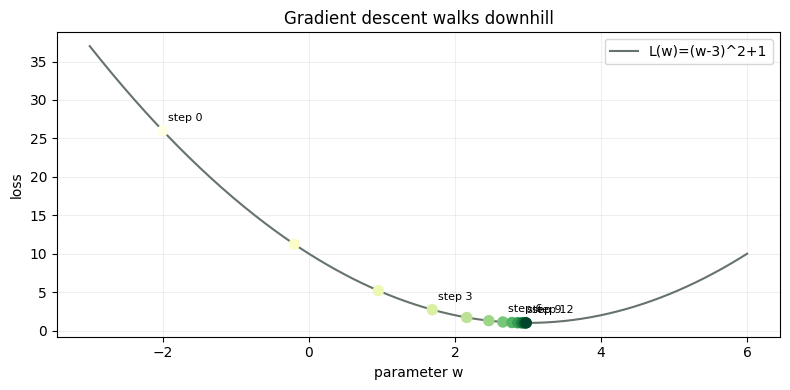

{'start': -2.0, 'after 12 steps': 2.9764, 'optimal': 3.0}


In [8]:
learning_rate = 0.18
w = -2.0
path = [w]
for _ in range(12):
    gradient = 2 * (w - 3)
    w = w - learning_rate * gradient
    path.append(w)

x = np.linspace(-3, 6, 300); loss_curve = (x - 3) ** 2 + 1
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, loss_curve, color="#66736b", label="L(w)=(w-3)^2+1")
ax.scatter(path, [(point-3)**2+1 for point in path], c=np.arange(len(path)), cmap="YlGn", s=52, zorder=3)
for step, point in enumerate(path[::3]): ax.annotate(f"step {step*3}", (point, (point-3)**2+1), xytext=(4, 7), textcoords="offset points", fontsize=8)
ax.set(title="Gradient descent walks downhill", xlabel="parameter w", ylabel="loss"); ax.grid(alpha=.2); ax.legend()
plt.tight_layout(); plt.show()
print({"start": path[0], "after 12 steps": round(path[-1], 4), "optimal": 3.0})

## 7. 训练集、测试集与推荐指标

模型在做过的题上得高分，不代表会做新题。因此必须：

1. **训练集**用来修改参数；
2. **验证集**用来选择超参数和停止时机；
3. **测试集**只在最后评估一次。

推荐系统还必须按时间切分：用过去预测未来，不能让未来行为泄漏进训练。下面用统一符号讲清指标：

- $u$：一位用户，$U$：参与评测的用户集合；
- $K$：只看推荐列表的前 $K$ 个位置；
- $R_u@K$：模型给用户 $u$ 的前 $K$ 个推荐；
- $G_u$：测试集中用户 $u$ 真正喜欢或点击的物品（ground truth）；
- $H_u@K=R_u@K\cap G_u$：推荐列表中的命中集合；
- $y_i$：真实标签或评分，$\hat y_i$：模型预测，$N$：样本数。

### 7.1 Top-K 集合指标：找得准、找得全、是否命中

**Precision@K（准确率）**问：“推荐出来的 $K$ 个物品中，有多少是对的？”

$$
\mathrm{Precision@K}(u)=\frac{|H_u@K|}{K}
$$

**Recall@K（召回率）**问：“用户真正喜欢的物品中，有多少被找回来了？”

$$
\mathrm{Recall@K}(u)=\frac{|H_u@K|}{|G_u|}
$$

**HitRate@K（命中率）**只关心有没有至少命中一个，不关心命中了几个：

$$
\mathrm{HitRate@K}=\frac{1}{|U|}\sum_{u\in U}\mathbb{I}(|H_u@K|>0)
$$

其中指示函数 $\mathbb I(\text{条件})$ 在条件成立时等于 1，否则等于 0。若每位用户测试集只有一个目标物品（leave-one-out），Recall@K 和 HitRate@K 数值相同；当每人有多个目标时二者不同。

**F1@K**是 Precision 与 Recall 的调和平均，只有两者都高时才会高：

$$
\mathrm{F1@K}=\frac{2\,\mathrm{Precision@K}\,\mathrm{Recall@K}}
{\mathrm{Precision@K}+\mathrm{Recall@K}}
$$

> 直觉：扩大 $K$ 通常会提高 Recall，却可能降低 Precision。因此比较模型时必须使用相同的 $K$。

In [9]:
# 一位用户的 Top-K 手算：5 个推荐里命中 2 个；真正相关物品有 3 个
recommended = ["i3", "i7", "i2", "i9", "i1"]
relevant = {"i2", "i3", "i8"}
hits = set(recommended) & relevant

precision_at_5 = len(hits) / len(recommended)
recall_at_5 = len(hits) / len(relevant)
hit_at_5 = float(len(hits) > 0)
f1_at_5 = 2 * precision_at_5 * recall_at_5 / (precision_at_5 + recall_at_5)

print({
    "hits": sorted(hits),
    "Precision@5": round(precision_at_5, 3),  # 2/5
    "Recall@5": round(recall_at_5, 3),        # 2/3
    "Hit@5": hit_at_5,                        # 至少命中一次
    "F1@5": round(f1_at_5, 3),
})

{'hits': ['i2', 'i3'], 'Precision@5': 0.4, 'Recall@5': 0.667, 'Hit@5': 1.0, 'F1@5': 0.5}


### 7.2 顺序敏感的列表指标：好东西是否排在前面

Precision/Recall 只看集合，不看命中的位置。推荐页面首屏尤其在意顺序。

**MRR（Mean Reciprocal Rank）**只看第一个相关结果的位置。若第一个命中在第 $r_u$ 位，则倒数排名为 $1/r_u$：

$$
\mathrm{MRR@K}=\frac{1}{|U|}\sum_{u\in U}
\begin{cases}
1/r_u,&r_u\le K\\
0,&\text{前 K 位无命中}
\end{cases}
$$

**DCG@K**允许每个结果有不同相关程度 $rel_{u,r}$，并用 $\log_2(r+1)$ 惩罚靠后的位置：

$$
\mathrm{DCG@K}(u)=\sum_{r=1}^{K}\frac{2^{rel_{u,r}}-1}{\log_2(r+1)}
$$

把相同物品按真实相关性从高到低排列可得到理想值 $\mathrm{IDCG@K}$。归一化以后，不同用户才方便平均：

$$
\mathrm{NDCG@K}(u)=\frac{\mathrm{DCG@K}(u)}{\mathrm{IDCG@K}(u)}\in[0,1]
$$

**AP@K（Average Precision）**在每个相关结果出现的位置计算 Precision，再取平均；**MAP@K**是所有用户 AP 的平均：

$$
\mathrm{AP@K}(u)=\frac{1}{\min(|G_u|,K)}
\sum_{r=1}^{K}\mathrm{Precision@r}(u)\cdot rel_{u,r},\qquad
\mathrm{MAP@K}=\frac{1}{|U|}\sum_u\mathrm{AP@K}(u)
$$

二值相关时 $rel_{u,r}\in\{0,1\}$。MRR 强调“第一次命中”，NDCG 能处理多档相关性，MAP 奖励把多个相关结果都提前。

In [10]:
# 同样命中两个物品，放在更靠前的位置会得到更高的 MRR / NDCG / AP
binary_relevance = np.array([1, 0, 1, 0, 0])
graded_relevance = np.array([3, 0, 1, 0, 0])

first_hit_rank = np.flatnonzero(binary_relevance)[0] + 1
mrr_at_5 = 1 / first_hit_rank

ranks = np.arange(1, len(graded_relevance) + 1)
discounts = np.log2(ranks + 1)
dcg_at_5 = np.sum((2**graded_relevance - 1) / discounts)
ideal = np.sort(graded_relevance)[::-1]
idcg_at_5 = np.sum((2**ideal - 1) / discounts)
ndcg_at_5 = dcg_at_5 / idcg_at_5

precision_at_each_rank = np.cumsum(binary_relevance) / ranks
ap_at_5 = np.sum(precision_at_each_rank * binary_relevance) / min(binary_relevance.sum(), 5)
print({"MRR@5": round(mrr_at_5, 3), "NDCG@5": round(ndcg_at_5, 3), "AP@5": round(ap_at_5, 3)})

{'MRR@5': np.float64(1.0), 'NDCG@5': np.float64(0.983), 'AP@5': np.float64(0.833)}


### 7.3 评分误差：预测值离真实值多远

**MAE（平均绝对误差）**直接平均距离，单位与原评分相同：

$$
\mathrm{MAE}=\frac{1}{N}\sum_{i=1}^{N}|y_i-\hat y_i|
$$

**RMSE（均方根误差）**先平方再平均，因此对少数大错误惩罚更重：

$$
\mathrm{RMSE}=\sqrt{\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat y_i)^2}
$$

二者都是越小越好。RMSE/MAE 适合 1～5 星等评分预测，却不保证 Top-K 排序更好。

### 7.4 概率与二分类排序：LogLoss、AUC 与 GAUC

点击率模型对样本 $i$ 输出概率 $p_i\in(0,1)$，真实标签 $y_i\in\{0,1\}$。

**LogLoss（二元交叉熵）**衡量概率预测本身是否可信，越小越好：

$$
\mathrm{LogLoss}=-\frac{1}{N}\sum_{i=1}^{N}
\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right]
$$

预测正确但不够自信仍会有小损失；非常自信地答错会受到巨大惩罚。因此 LogLoss 同时关心区分能力和概率质量。

**AUC**等价于随机抽一个正样本 $+$ 和一个负样本 $-$，正样本得分更高的概率：

$$
\mathrm{AUC}=P(s^+>s^-)+\frac{1}{2}P(s^+=s^-)
$$

AUC 为 0.5 表示接近随机排序，1 表示所有正样本都在负样本前。它只关心顺序：对所有分数做保持顺序的变换，AUC 不变，但 LogLoss 可能明显变化。

工业推荐常计算每位用户内部的 AUC，再按该用户曝光数 $n_u$ 加权，称为 **GAUC**：

$$
\mathrm{GAUC}=\frac{\sum_{u\in U'}n_u\,\mathrm{AUC}_u}{\sum_{u\in U'}n_u}
$$

$U'$ 只包含同时具有正、负样本的用户。GAUC 避免“用户之间本来就有不同点击率”虚增全局 AUC，更接近同一用户内部的排序质量。

In [11]:
# 用 NumPy 手算评分、概率和排序指标
true_ratings = np.array([5.0, 3.0, 1.0, 4.0])
pred_ratings = np.array([4.5, 2.0, 2.0, 4.0])
mae = np.mean(np.abs(true_ratings - pred_ratings))
rmse = np.sqrt(np.mean((true_ratings - pred_ratings) ** 2))

labels = np.array([1, 0, 1, 0, 1, 0])
probabilities_for_metric = np.array([.9, .8, .7, .4, .6, .2])
eps = 1e-12
logloss = -np.mean(labels*np.log(probabilities_for_metric+eps) + (1-labels)*np.log(1-probabilities_for_metric+eps))
positive_scores = probabilities_for_metric[labels == 1]
negative_scores = probabilities_for_metric[labels == 0]
pairwise_auc = np.mean(
    (positive_scores[:, None] > negative_scores[None, :])
    + 0.5 * (positive_scores[:, None] == negative_scores[None, :])
)

print({"MAE": round(mae, 3), "RMSE": round(rmse, 3), "LogLoss": round(logloss, 3), "AUC": round(float(pairwise_auc), 3)})

{'MAE': np.float64(0.625), 'RMSE': np.float64(0.75), 'LogLoss': np.float64(0.553), 'AUC': 0.778}


### 7.5 覆盖率与指标选择

准确率高不代表所有用户都在看到丰富的目录。**Catalog Coverage@K** 衡量全部用户的 Top-K 列表一共触达多少种物品：

$$
\mathrm{Coverage@K}=\frac{|\bigcup_{u\in U}R_u@K|}{|I|}
$$

其中 $I$ 是可推荐物品全集。Coverage 越高说明系统不只反复推荐少数热门物品，但覆盖率不能单独代表相关性或用户满意度。

| 任务问题 | 优先指标 | 必须搭配观察 |
|---|---|---|
| 百万物品召回是否漏掉目标 | Recall@K、HitRate@K | Coverage、延迟、分人群 Recall |
| Top-K 列表是否把好内容提前 | NDCG@K、MAP@K、MRR | Recall@K、多样性 |
| 星级评分是否接近真实值 | RMSE、MAE | Top-K 指标 |
| CTR/CVR 排序是否正确 | AUC、GAUC | LogLoss、校准、分桶稳定性 |

用户平均通常采用 **macro average**：先算每位用户的指标，再对用户平均，让每位用户权重相同；把所有命中数和分母先汇总再相除是 **micro average**，活跃用户会占更大权重。论文或报表必须明确平均方式、$K$、负样本策略和时间切分，否则数值不可复现。

In [12]:
catalog = {"i1", "i2", "i3", "i4", "i5", "i6", "i7", "i8", "i9", "i10"}
recommendations_by_user = {
    "u1": ["i3", "i7", "i2"],
    "u2": ["i1", "i7", "i5"],
    "u3": ["i3", "i9", "i5"],
}
exposed_items = set().union(*map(set, recommendations_by_user.values()))
coverage_at_3 = len(exposed_items) / len(catalog)
print({"exposed_items": sorted(exposed_items), "Catalog Coverage@3": round(coverage_at_3, 3)})

{'exposed_items': ['i1', 'i2', 'i3', 'i5', 'i7', 'i9'], 'Catalog Coverage@3': 0.6}


## Checks

这些检查不是为了“证明数学”，而是训练把公式翻译成可验证事实的习惯：矩阵尺寸正确、相似度在合法范围、Sigmoid 输出是概率、梯度下降确实降低损失、指标位于 0～1。

In [13]:
assert user_cooccurrence.shape == (3, 3)
assert item_cooccurrence.shape == (4, 4)
assert 0 <= cosine <= 1
assert np.all((probabilities > 0) & (probabilities < 1))
assert (path[-1] - 3) ** 2 < (path[0] - 3) ** 2
assert 0 <= precision_at_5 <= 1 and 0 <= recall_at_5 <= 1 and 0 <= f1_at_5 <= 1
assert 0 <= mrr_at_5 <= 1 and 0 <= ndcg_at_5 <= 1 and 0 <= ap_at_5 <= 1
assert mae <= rmse and 0 <= pairwise_auc <= 1 and logloss >= 0
assert 0 <= coverage_at_3 <= 1
print("PASS：矩阵、相似度、概率、优化和指标示例全部通过。")

PASS：矩阵、相似度、概率、优化和指标示例全部通过。


## Next Steps

现在可以进入 3.1：

- UserCF / ItemCF 会复用矩阵乘法和余弦相似度；
- MF 会把一个大矩阵近似拆成两个较小矩阵；
- FM 会复用点积来共享稀疏特征交互；
- GBDT+LR 会复用 Sigmoid、概率和 LogLoss。

遇到公式时，按四步阅读：**每个符号代表什么 → 数组形状是什么 → 用小数字手算一遍 → 用代码检查**。不需要先记住公式。